# VeriPromiseESG 2026 ESG 承諾驗證工作坊
## 使用 RoBERTa 進行多任務分類

**工作坊時間**: 約 60 分鐘  
**難度**: 中級（需具備基礎 Python 知識）

### 今天的學習目標
1. 了解 ESG（環境、社會、治理）承諾驗證任務
2. 掌握如何使用 RoBERTa 進行多標籤分類
3. 實作完整的訓練與評估流程

### 任務說明
給定一段 ESG 報告文字，模型需要同時預測四個欄位：
| 欄位 | 說明 | 類別 |
|------|------|------|
| \ | 是否有承諾 | Yes / No |
| \ | 承諾時程 | already / within_2_years / between_2_and_5_years / longer_than_5_years / N/A |
| \ | 是否有佐證 | Yes / No / N/A |
| \ | 佐證品質 | Clear / Not Clear / Misleading / N/A |

### Related Links
- Competition Main Website：https://veripromiseesg.github.io/
- AI CUP Main Website：https://www.aicup.tw/
- AI CUP Competition Registration Website：https://go.aicup.tw/
- AIDEA Competition Website：https://www.aidea-web.tw/aicup_veripromiseesg
### Reference Links
- SemEval-2025 Task 6: Multinational, Multilingual, Multi-Industry Promise Verification：https://aclanthology.org/2025.semeval-1.321/
- ML-Promise: A Multilingual Dataset for Corporate Promise Verification：https://aclanthology.org/2025.emnlp-main.1028/
- Multilingual Promise Verification in ESG Reports with Large Language Model Performance Evaluation：https://aclanthology.org/2025.rocling-main.32/
- NTCIR：https://research.nii.ac.jp/ntcir/index-en.html

## Step 1: 安裝套件

首先安裝必要的 Python 套件。在 Google Colab 上執行以下指令。

> **說明**：
> - `transformers` — HuggingFace 提供的預訓練模型庫
> - `torch` — PyTorch 深度學習框架
> - `scikit-learn` — 評估指標計算
> - `pandas` / `matplotlib` — 資料分析與視覺化

In [ ]:
# 安裝必要套件（Colab 環境）
!pip install transformers torch scikit-learn pandas matplotlib seaborn -q
print("套件安裝完成！")

套件安裝完成！


In [ ]:
# RAG要用
!pip install sentence-transformers faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 89.1 MB/s eta 0:00:00


In [ ]:
# 從 GitHub 下載公開資料集（不需要 Google Drive）
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/veripromiseesg/veripromiseesgdataset/ac91c1c8b5d116edf6fc44cccc1ee3b618f5a207/vpesg4ktrain1000v1.json"
urllib.request.urlretrieve(DATA_URL, "vpesg4k_train_1000.json")
print("資料下載完成！")

資料下載完成！


In [ ]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, RobertaModel, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 中文字型設定（Colab）
matplotlib.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('套件載入完成！')
print(f'PyTorch 版本: {torch.__version__}')
print(f'CUDA 可用: {torch.cuda.is_available()}')

套件載入完成！
PyTorch 版本: 2.11.0+cu128
CUDA 可用: True


---

## Step 2: 設定超參數與標籤對應

在開始之前，我們先定義所有重要的超參數與標籤映射表。

### 重要參數說明
- **MODEL_NAME**: 使用 `hfl/chinese-roberta-wwm-ext`，這是哈工大發布的中文 RoBERTa 模型
- **MAX_LEN**: 輸入文字的最大 Token 長度（256）
- **BATCH_SIZE**: 每次訓練的樣本數（16）
- **EPOCHS**: 訓練完整資料集的次數（5）
- **LR**: 學習率，建議 RoBERTa fine-tuning 使用 2e-5

### 為什麼用 chinese-roberta-wwm-ext？
RoBERTa（Robustly Optimized BERT Pretraining Approach）是 BERT 的改進版本。
- 移除了 Next Sentence Prediction（NSP）任務
- 使用更大的 batch size 與更長的訓練時間
- 採用全詞遮罩（Whole Word Masking, WWM）策略，更適合中文
- 在多項中文 NLP 任務上優於 bert-base-chinese

In [ ]:
# ============================================================
# 超參數設定
# ============================================================
MODEL_NAME = "bert-base-chinese"
MAX_LEN = 416
BATCH_SIZE = 8    # 資料集較小（1000筆），使用小 batch size
EPOCHS = 15       # 資料少，多訓練幾個 epoch
LR = 1e-5
WARMUP_RATIO = 0.1

# 四個預測欄位及其標籤（依照競賽官方規格定義）
EVAL_FIELDS = {
    "promise_status": ["Yes", "No"],
    "verification_timeline": ["already", "within_2_years", "between_2_and_5_years", "longer_than_5_years", "N/A"],
    "evidence_status": ["Yes", "No", "N/A"],
    "evidence_quality": ["Clear", "Not Clear", "Misleading", "N/A"]
}

# 各欄位的評分權重（依照競賽規則）
FIELD_WEIGHTS = {
    "promise_status": 0.2,
    "verification_timeline": 0.15,
    "evidence_status": 0.3,
    "evidence_quality": 0.35
}

# 建立標籤到 ID 的映射
label2id = {field: {label: i for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
id2label = {field: {i: label for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
num_labels = {field: len(labels) for field, labels in EVAL_FIELDS.items()}

print('超參數設定完成！')
print(f'使用模型: {MODEL_NAME}')
print(f'最大長度: {MAX_LEN}')
print(f'批次大小: {BATCH_SIZE}')
print(f'訓練輪數: {EPOCHS}')
print(f'標籤數量: {num_labels}')

超參數設定完成！
使用模型: bert-base-chinese
最大長度: 416
批次大小: 8
訓練輪數: 15
標籤數量: {'promise_status': 2, 'verification_timeline': 5, 'evidence_status': 3, 'evidence_quality': 4}


---

## Step 3: 載入資料
載入剛才下載的 JSON 檔案，並切分為訓練集（80%）與驗證集（20%）。

> **說明**：這份資料共 1,000 筆，來自台灣上市公司的 ESG 永續報告書。

In [ ]:
from sklearn.model_selection import KFold
import json
import pandas as pd

# ================================
# Step 3: 載入 train + 官方 val 並合併
# ================================

# 讀取原本 train_1000
with open("vpesg4k_train_1000.json", "r", encoding="utf-8") as f:
    train_json_data = json.load(f)

# 讀取官方 val_1000
val_df = pd.read_csv("vpesg4k_val_1000.csv")
val_csv_data = val_df.to_dict("records")

# 合併成新的訓練資料 2000 筆
all_data = train_json_data + val_csv_data


# ================================
# 統一 label 名稱與處理空值
# ================================

def normalize_labels(item):
    for field in EVAL_FIELDS.keys():
        if field in item:
            value = item[field]

            # 處理真正的 NaN
            if pd.isna(value):
                item[field] = "N/A"
            else:
                value = str(value).strip()

                # 處理字串型 nan / none / 空字串
                if value.lower() in ["nan", "none", ""]:
                    item[field] = "N/A"
                else:
                    item[field] = value

    # 官方格式 more_than_5_years 轉成程式內部用的 longer_than_5_years
    if item.get("verification_timeline") == "more_than_5_years":
        item["verification_timeline"] = "longer_than_5_years"

    # 統一大小寫
    if item.get("evidence_quality") == "Not clear":
        item["evidence_quality"] = "Not Clear"

    return item


all_data = [normalize_labels(item) for item in all_data]


# ================================
# 檢查合併結果
# ================================

print("train 筆數:", len(train_json_data))
print("val 筆數:", len(val_csv_data))
print("合併後 all_data 筆數:", len(all_data))
print("欄位:", all_data[0].keys())

print("\n檢查所有欄位實際出現的 label：")

for field, labels in EVAL_FIELDS.items():
    actual_labels = sorted(set(str(item[field]) for item in all_data))
    expected_labels = set(labels)
    actual_set = set(actual_labels)

    print("\n", field)
    print("實際出現:", actual_labels)
    print("程式允許:", labels)
    print("多出來的:", actual_set - expected_labels)
    print("缺少的:", expected_labels - actual_set)


# ================================
# 建立 5-Fold Cross Validation
# ================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, val_idx) in enumerate(kf.split(all_data)):
    train_data = [all_data[i] for i in train_idx]
    val_data = [all_data[i] for i in val_idx]

    print(f"\nFold {fold + 1}")
    print(f"   訓練集大小: {len(train_data)} 筆")
    print(f"   驗證集大小: {len(val_data)} 筆")

train 筆數: 1000
val 筆數: 1000
合併後 all_data 筆數: 2000
欄位: dict_keys(['id', 'data', 'esg_type', 'promise_status', 'promise_string', 'verification_timeline', 'evidence_status', 'evidence_string', 'evidence_quality', 'company', 'ticker', 'page_number', 'pdf_url', 'company_source'])

檢查所有欄位實際出現的 label：

 promise_status
實際出現: ['No', 'Yes']
程式允許: ['Yes', 'No']
多出來的: set()
缺少的: set()

 verification_timeline
實際出現: ['N/A', 'already', 'between_2_and_5_years', 'longer_than_5_years', 'within_2_years']
程式允許: ['already', 'within_2_years', 'between_2_and_5_years', 'longer_than_5_years', 'N/A']
多出來的: set()
缺少的: set()

 evidence_status
實際出現: ['N/A', 'No', 'Yes']
程式允許: ['Yes', 'No', 'N/A']
多出來的: set()
缺少的: set()

 evidence_quality
實際出現: ['Clear', 'Misleading', 'N/A', 'Not Clear']
程式允許: ['Clear', 'Not Clear', 'Misleading', 'N/A']
多出來的: set()
缺少的: set()

Fold 1
   訓練集大小: 1600 筆
   驗證集大小: 400 筆

Fold 2
   訓練集大小: 1600 筆
   驗證集大小: 400 筆

Fold 3
   訓練集大小: 1600 筆
   驗證集大小: 400 筆

Fold 4
   訓練集大小: 1600 筆
   驗證集大小: 

---

## Step 4: 探索性資料分析（EDA）

在訓練模型前，先深入了解資料的特性，這一步非常重要！

我們要觀察：
1. 資料的欄位結構
2. 各標籤的分佈（是否不均衡？）
3. 文字長度分佈
4. 範例資料內容

In [ ]:
# 觀察單筆資料結構
sample = train_data[0]
print("範例資料欄位：")
print("-" * 50)
for key, value in sample.items():
    if key == "data":
        print(f"  {key}: {str(value)[:100]}...")
    else:
        print(f"  {key}: {value}")

範例資料欄位：
--------------------------------------------------
  id: 10001
  data: 聯發科技除在「工作規則」中依照勞基法明確規定「員工在產假期間公司不得終止勞動契約」外，為支持同仁與其家人度過人生不同階段，自 2024 年起提供女性員工在分娩前後計有 12 週共 84 天的產假；男性...
  esg_type: S
  promise_status: Yes
  promise_string: 為支持同仁與其家人度過人生不同階段，自 2024 年起提供女性員工在分娩前後計有 12 週共 84 天的產假；男性員工則可於其配偶懷孕期間陪同產檢或生（流）產日及前後 15 日間請假陪伴，兩者合計共有 10 天陪產（檢）假可運用，陪產（檢）假期間工資照常給付。
  verification_timeline: already
  evidence_status: No
  evidence_string: 
  evidence_quality: N/A
  company: mediatek
  ticker: 2454
  page_number: 48
  pdf_url: https://hsxn1sjvkgtdpixe.public.blob.vercel-storage.com/mediatek_2454_page_48.pdf
  company_source: https://corp.mediatek.tw/about/sustainability


In [ ]:
# 轉換為 DataFrame 方便分析
train_df = pd.DataFrame(train_data)
val_df = pd.DataFrame(val_data)

print("訓練集欄位類型：")
print(train_df.dtypes)
print(f"\n訓練集欄位：{list(train_df.columns)}")

訓練集欄位類型：
id                        int64
data                     object
esg_type                 object
promise_status           object
promise_string           object
verification_timeline    object
evidence_status          object
evidence_string          object
evidence_quality         object
company                  object
ticker                    int64
page_number               int64
pdf_url                  object
company_source           object
dtype: object

訓練集欄位：['id', 'data', 'esg_type', 'promise_status', 'promise_string', 'verification_timeline', 'evidence_status', 'evidence_string', 'evidence_quality', 'company', 'ticker', 'page_number', 'pdf_url', 'company_source']


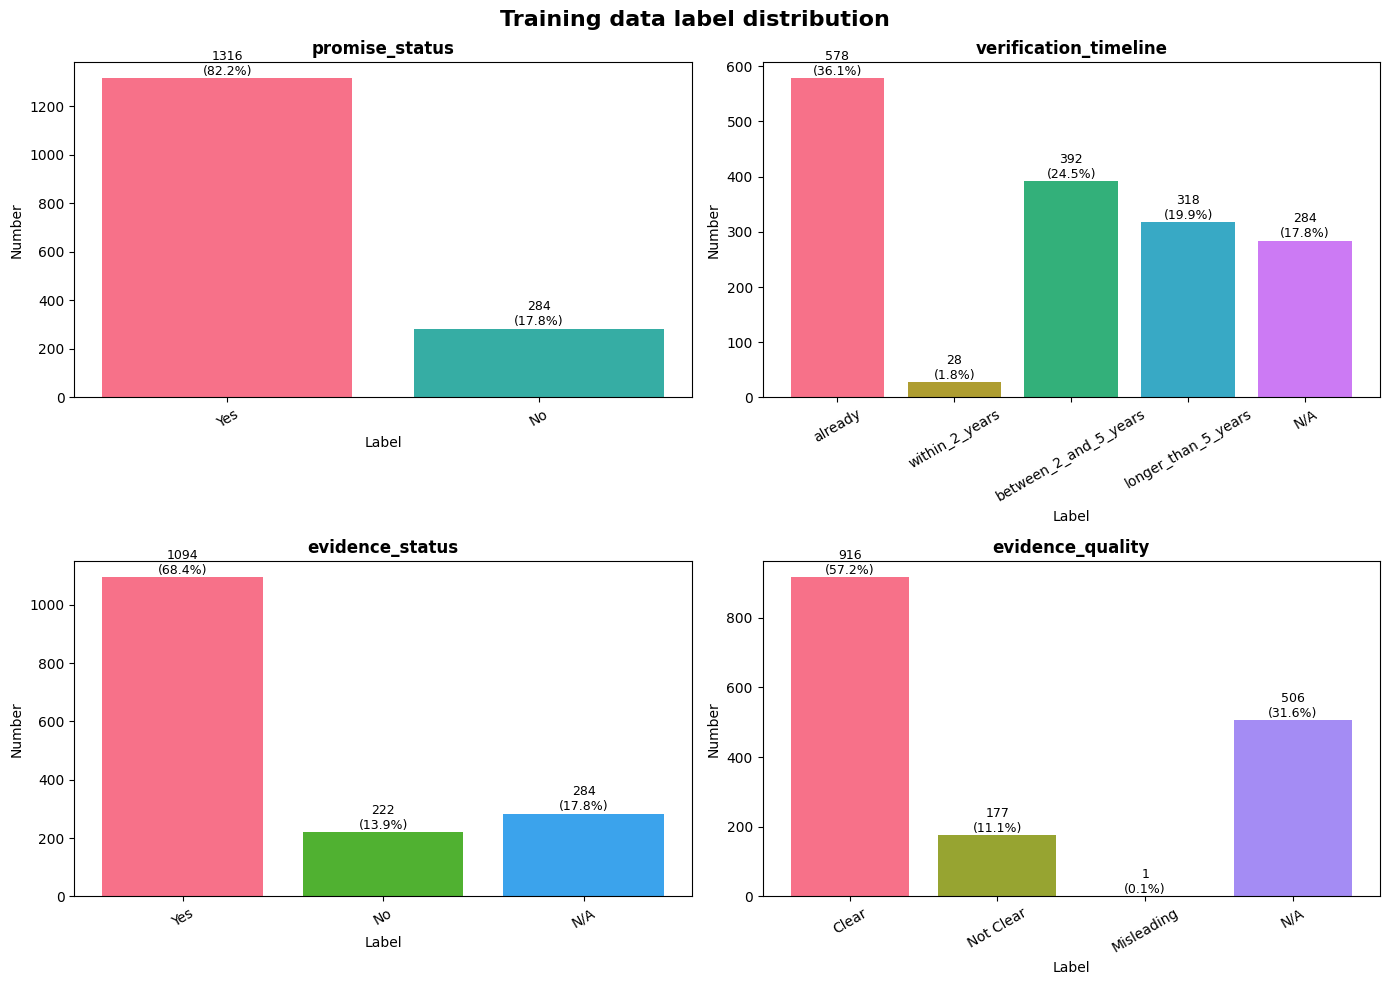

觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數


In [ ]:
# 視覺化各欄位的標籤分佈
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training data label distribution", fontsize=16, fontweight='bold')

for idx, (field, labels) in enumerate(EVAL_FIELDS.items()):
    ax = axes[idx // 2][idx % 2]

    counts = Counter(train_df[field])
    ordered_counts = {label: counts.get(label, 0) for label in labels}

    bars = ax.bar(ordered_counts.keys(), ordered_counts.values(),
                   color=sns.color_palette("husl", len(labels)))
    ax.set_title(f"{field}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Label")
    ax.set_ylabel("Number")
    ax.tick_params(axis='x', rotation=30)

    # 在每個bar上顯示數量
    for bar, (label, count) in zip(bars, ordered_counts.items()):
        total = sum(ordered_counts.values())
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數")

In [ ]:
# ============================================================
# 【新增】計算 TF-IDF 與 LSA 特徵
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

print("正在生成 TF-IDF 與 LSA 統計特徵...")
# 1. 提取所有文字（包含訓練與驗證集）
all_texts_for_tfidf = [item['data'] for item in all_data]

# 2. 計算 TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(all_texts_for_tfidf)

# 3. 使用 LSA (SVD) 降維至 128 維 [cite: 323, 355, 362]
lsa_obj = TruncatedSVD(n_components=128, random_state=42)
lsa_features = lsa_obj.fit_transform(tfidf_matrix)

# 4. 將特徵存回原始資料字典中
for i, item in enumerate(all_data):
    item['lsa_feature'] = lsa_features[i]

print(f"✅ LSA 特徵生成完成，維度: {lsa_features.shape}")

正在生成 TF-IDF 與 LSA 統計特徵...
✅ LSA 特徵生成完成，維度: (2000, 128)


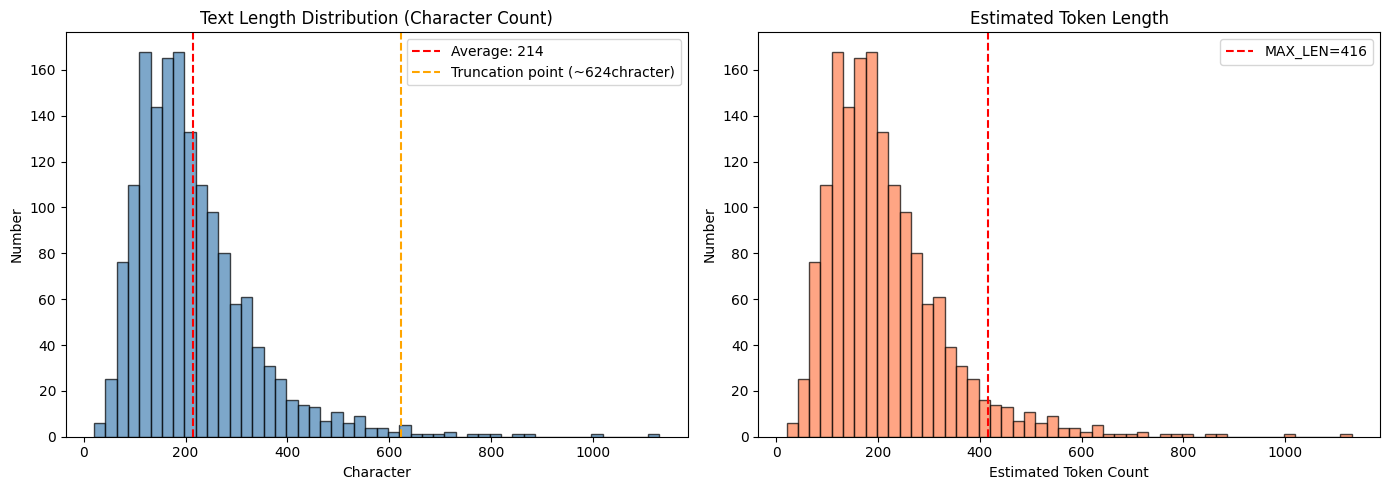

超過 MAX_LEN=416 的樣本數: 87 (5.4%)
   這些文字將被截斷，可能損失尾端資訊


In [ ]:
# 分析文字長度分佈（字元數）
train_df['text_length'] = train_df['data'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['text_length'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(train_df['text_length'].mean(), color='red', linestyle='--',
                label=f"Average: {train_df['text_length'].mean():.0f}")
axes[0].axvline(MAX_LEN * 1.5, color='orange', linestyle='--',
                label=f"Truncation point (~{MAX_LEN * 1.5:.0f}chracter)")
axes[0].set_title("Text Length Distribution (Character Count)")
axes[0].set_xlabel("Character")
axes[0].set_ylabel("Number")
axes[0].legend()

# Token 長度估算（中文約 1字 = 1 token）
axes[1].hist(train_df['text_length'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(MAX_LEN, color='red', linestyle='--', label=f"MAX_LEN={MAX_LEN}")
axes[1].set_title("Estimated Token Length")
axes[1].set_xlabel("Estimated Token Count")
axes[1].set_ylabel("Number")
axes[1].legend()

plt.tight_layout()
plt.show()

truncated = (train_df['text_length'] > MAX_LEN).sum()
print(f"超過 MAX_LEN={MAX_LEN} 的樣本數: {truncated} ({truncated/len(train_df)*100:.1f}%)")
print(f"   這些文字將被截斷，可能損失尾端資訊")

In [ ]:
# ============================================================
# 【新增】計算權重補償 (Step A)
# ============================================================
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("正在計算各欄位類別權重...")
field_weights_tensors = {}

# 確保在計算時使用與訓練相同的 device
calc_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for field, labels in EVAL_FIELDS.items():
    # 取得訓練集該欄位的所有標籤
    y_labels = [item[field] for item in train_data]

    # 計算平衡權重 (Balanced Weights)
    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.array(labels),
        y=y_labels
    )
    # 轉成 Tensor 並放到 GPU/CPU
    field_weights_tensors[field] = torch.tensor(weights, dtype=torch.float).to(calc_device)

print("✅ 權重計算完成！")

正在計算各欄位類別權重...
✅ 權重計算完成！


---

## Step 5: 建立 PyTorch Dataset

PyTorch 的 `Dataset` 類別負責：
1. 儲存資料
2. 將文字 **Tokenize**（轉換成 BERT 能理解的 Token ID）
3. 將標籤文字轉換成數字 ID

### Tokenization 是什麼？
BERT 使用 WordPiece tokenizer 將文字切成子詞單元：
- 輸入: `"台灣水泥承諾2030年碳中和"`
- 輸出: `[101, 1921, 3968, 3717, 3686, 8811, 2030, 2399, 4988, 102, ...]`
  - `101` = [CLS] 開始符號
  - `102` = [SEP] 結束符號

### Padding & Truncation
所有輸入必須等長（MAX_LEN=256），所以：
- 短文字 → 補 0（padding）
- 長文字 → 截斷（truncation）

In [ ]:
# 示範 Tokenizer 的效果
print('Tokenizer 示範')
print('=' * 50)

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f'載入 {MODEL_NAME} tokenizer')

sample_text = train_data[0]['data'][:50]
print(f'原始文字：{sample_text}')

tokens = tokenizer.tokenize(sample_text)
print(f'Tokenize 後：{tokens}')

encoding = tokenizer(sample_text, max_length=20, padding='max_length', truncation=True)
print(f"Input IDs (前20個)：{encoding['input_ids']}")
print(f"Attention Mask：{encoding['attention_mask']}")

Tokenizer 示範


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/269k [00:00<?, ?B/s]

載入 bert-base-chinese tokenizer
原始文字：聯發科技除在「工作規則」中依照勞基法明確規定「員工在產假期間公司不得終止勞動契約」外，為支持同仁與其
Tokenize 後：['聯', '發', '科', '技', '除', '在', '「', '工', '作', '規', '則', '」', '中', '依', '照', '勞', '基', '法', '明', '確', '規', '定', '「', '員', '工', '在', '產', '假', '期', '間', '公', '司', '不', '得', '終', '止', '勞', '動', '契', '約', '」', '外', '，', '為', '支', '持', '同', '仁', '與', '其']
Input IDs (前20個)：[101, 5474, 4634, 4906, 2825, 7370, 1762, 519, 2339, 868, 6211, 1179, 520, 704, 898, 4212, 1246, 1825, 3791, 102]
Attention Mask：[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
# 1. 定義特徵掃描函數
def build_feature_prefix(text):
    prefix = ""
    # 1. 識別年份 (時程判斷)
    if any(yr in text for yr in ["202", "203", "204", "205"]):
        prefix += "[YEAR] "
    # 2. 識別數據 (佐證強度)
    if "%" in text or "百分之" in text or any(c.isdigit() for c in text):
        prefix += "[DATA] "
    # 3. 【新增】識別驗證關鍵字 (針對佐證品質)
    # 這些詞彙能幫助模型區分 Clear 與 Not Clear
    verified_keywords = ["通過", "驗證", "核查", "證書", "ISO", "認證", "第三方", "查證"]
    if any(w in text for w in verified_keywords):
        prefix += "[VERIFIED] "
    return prefix

# 2. 修改 Dataset 類別
class ESGDataset(Dataset):
    def __init__(self, data, tokenizer, label2id):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        original_text = item['data']
        lsa_feat = torch.tensor(item['lsa_feature'], dtype=torch.float)

        # 拼接手動特徵、原始文字與 RAG 資訊
        feature_prefix = build_feature_prefix(original_text)
        combined_text = f"{feature_prefix}{original_text}"

        encoding = self.tokenizer(
            combined_text,
            truncation=True,
            max_length=MAX_LEN, # 目前設定為 416
            padding='max_length',
            return_tensors='pt'
        )

        # 【核心修正】：將編碼結果與標籤封裝並回傳
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        # 轉換標籤文字為 ID
        labels = {
            field: torch.tensor(self.label2id[field][item[field]], dtype=torch.long)
            for field in EVAL_FIELDS
        }

        # 必須要有這個 return，collate_fn 才能運作
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'lsa_feat': lsa_feat, # 新增這一行
            'labels': labels
        }

def collate_fn(batch):
    """
    自定義 collate_fn，用於 DataLoader 批次處理
    將多個樣本的 input_ids, attention_mask 和各任務的 labels 堆疊成批次張量
    """
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])

    lsa_feat = torch.stack([item['lsa_feat'] for item in batch])

    labels = {
        field: torch.stack([item['labels'][field] for item in batch])
        for field in EVAL_FIELDS
    }

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'lsa_feat': lsa_feat, # 新增
        'labels': labels
    }

# 建立 Dataset 實例
train_dataset = ESGDataset(train_data, tokenizer, label2id)
val_dataset   = ESGDataset(val_data,   tokenizer, label2id)

# 建立 DataLoader（負責批次載入資料）
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # 訓練時打亂順序
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,         # 驗證時不打亂
    collate_fn=collate_fn
)

print(f"DataLoader 建立完成！")
print(f"   訓練集 Batch 數: {len(train_loader)}")
print(f"   驗證集 Batch 數: {len(val_loader)}")

# 查看一個 batch 的結構
sample_batch = next(iter(train_loader))
print(f"\nBatch 結構：")
print(f"   input_ids shape: {sample_batch['input_ids'].shape}  # [batch_size, seq_len]")
print(f"   attention_mask shape: {sample_batch['attention_mask'].shape}")
for field, tensor in sample_batch['labels'].items():
    print(f"   labels['{field}'] shape: {tensor.shape}")

DataLoader 建立完成！
   訓練集 Batch 數: 200
   驗證集 Batch 數: 50

Batch 結構：
   input_ids shape: torch.Size([8, 416])  # [batch_size, seq_len]
   attention_mask shape: torch.Size([8, 416])
   labels['promise_status'] shape: torch.Size([8])
   labels['verification_timeline'] shape: torch.Size([8])
   labels['evidence_status'] shape: torch.Size([8])
   labels['evidence_quality'] shape: torch.Size([8])


---

## Step 6: 模型架構設計

我們使用 **Multi-Task Learning（多任務學習）**：
- 共用同一個 RoBERTa backbone（特徵提取器）
- 每個任務有自己獨立的分類頭（Linear Layer）

### 架構圖
```
文字輸入
   ↓
[RoBERTa Encoder] × 12 層 Transformer
   ↓
[CLS] Token 向量 (768維)
   ↓
┌──────────────────────────────────────────┐
│  promise_status    → Linear(768, 2)  → 2個類別  │
│  verification_timeline → Linear(768, 5) → 5個類別  │
│  evidence_status   → Linear(768, 3)  → 3個類別  │
│  evidence_quality  → Linear(768, 4)  → 4個類別  │
└──────────────────────────────────────────┘
```

### 為什麼用 [CLS] Token？
RoBERTa 的第一個 token `[CLS]` 的輸出向量被設計用於表示整個句子的語意，
因此適合用於句子分類任務。

In [ ]:
from transformers import BertModel
import torch
import torch.nn as nn

class MultiTaskBert(nn.Module):

    def __init__(self, num_labels_dict, lsa_dim=128):

        super().__init__()

        # ========================================================
        # 載入 BERT 主模型
        # ========================================================
        self.bert = BertModel.from_pretrained(MODEL_NAME)

        hidden_size = self.bert.config.hidden_size

        # ========================================================
        # Attention Pooling
        # ========================================================
        self.attention = nn.Sequential(

            nn.Linear(hidden_size, 128),

            nn.Tanh(),

            nn.Linear(128, 1)

        )

        # ========================================================
        # 最終特徵維度
        #
        # CLS                 : 768
        # Mean Pooling        : 768
        # Attention Pooling   : 768
        # LSA                 : 128
        #
        # 總共：
        # 2432
        # ========================================================
        self.feature_dim = (hidden_size * 3) + lsa_dim

        # ========================================================
        # 多任務分類器
        # ========================================================
        self.classifiers = nn.ModuleDict({

            field: nn.Sequential(

                nn.Linear(self.feature_dim, 256),

                nn.LayerNorm(256),

                nn.Dropout(0.2),

                nn.ReLU(),

                nn.Linear(256, n)

            )

            for field, n in num_labels_dict.items()

        })

    # ============================================================
    # Forward
    # ============================================================
    def forward(self, input_ids, attention_mask, lsa_feat):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # ========================================================
        # CLS 向量
        # ========================================================
        cls_output = outputs.pooler_output

        # ========================================================
        # Hidden States
        # shape:
        # [batch_size, seq_len, hidden_size]
        # ========================================================
        last_hidden = outputs.last_hidden_state

        # ========================================================
        # Mean Pooling
        # ========================================================
        mask = attention_mask.unsqueeze(-1).expand(
            last_hidden.size()
        ).float()

        mean_output = torch.sum(
            last_hidden * mask,
            1
        ) / torch.clamp(mask.sum(1), min=1e-9)

        # ========================================================
        # Attention Pooling
        # ========================================================

        # attention score
        attn_scores = self.attention(last_hidden).squeeze(-1)

        # mask padding token
        attn_scores = attn_scores.masked_fill(
            attention_mask == 0,
            -1e9
        )

        # softmax
        attn_weights = torch.softmax(attn_scores, dim=1)

        # weighted sum
        attention_output = torch.sum(
            last_hidden * attn_weights.unsqueeze(-1),
            dim=1
        )

        # ========================================================
        # 拼接所有特徵
        # ========================================================
        combined = torch.cat(
            (
                cls_output,
                mean_output,
                attention_output,
                lsa_feat
            ),
            dim=1
        )

        # ========================================================
        # Multi-task logits
        # ========================================================
        logits = {

            field: clf(combined)

            for field, clf in self.classifiers.items()

        }

        return logits


# ============================================================
# 計算模型參數量
# ============================================================

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(f'使用裝置: {device}')

model = MultiTaskBert(num_labels).to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f'模型參數量：')
print(f'   總參數: {total_params:,}')
print(f'   可訓練參數: {trainable_params:,}')
print(f'   （BERT-base 本身約 1.1 億參數）')

使用裝置: cuda


config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/412M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


模型參數量：
   總參數: 104,863,247
   可訓練參數: 104,863,247
   （BERT-base 本身約 1.1 億參數）


**幫助模型聚焦在難分樣本上**

In [ ]:
import torch.nn.functional as F

# ============================================================
# 【替換】具備權重補償功能的 WeightedFocalLoss (Step B-1)
# ============================================================
class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha_dict, gamma=2):
        super(WeightedFocalLoss, self).__init__()
        self.alpha_dict = alpha_dict  # 接收剛才計算的 field_weights_tensors
        self.gamma = gamma

    def forward(self, logits, targets, field_name):
        # 取得該欄位專屬的權重向量
        alpha = self.alpha_dict[field_name]

        # 使用 CrossEntropy 計算基礎 Loss，傳入權重 alpha
        ce_loss = F.cross_entropy(logits, targets, weight=alpha, reduction='none')
        pt = torch.exp(-ce_loss)

        # Focal Loss 公式
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

---

## Step 7: 定義訓練與評估函數

### 損失函數
我們使用 **CrossEntropyLoss**（交叉熵損失），適用於多分類問題。

對於多任務，損失 = 各任務損失的加總：
```
total_loss = loss(promise_status) + loss(timeline) + loss(evidence_status) + loss(evidence_quality)
```

### 優化器與學習率排程
- **AdamW**：Adam 的改進版，加入 weight decay 防止過擬合
- **Linear Warmup + Decay**：先線性增加學習率（warmup），再線性衰減
  - 前 10% 步數：學習率從 0 增加到 LR
  - 後 90% 步數：學習率從 LR 線性衰減到 0

### Gradient Clipping
`clip_grad_norm_(model.parameters(), 1.0)` — 防止梯度爆炸，將梯度範數裁剪到最大為 1.0

In [ ]:
# ============================================================
# 【修改】訓練函數以支援權重 Loss (Step B-2)
# ============================================================
def train_one_epoch(model, dataloader, optimizer, scheduler, device, weights_dict):
    model.train()
    total_loss = 0
    # 初始化剛才定義的新 Loss
    criterion = WeightedFocalLoss(weights_dict, gamma=2)

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            lsa_feat=batch["lsa_feat"].to(device) # 新增
        )

        # 在計算各欄位 Loss 時，多傳入一個欄位名稱 'field'
        loss = sum(
            FIELD_WEIGHTS[field] * criterion(logits[field], batch["labels"][field].to(device), field)
            for field in EVAL_FIELDS
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

# ============================================================
# evidence_quality 專用 retrain：新增這個
# ============================================================
def retrain_evidence_quality_one_epoch(model, dataloader, optimizer, scheduler, device, weights_dict):
    model.train()
    total_loss = 0
    criterion = WeightedFocalLoss(weights_dict, gamma=2)

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        lsa_feat = batch["lsa_feat"].to(device)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            lsa_feat=lsa_feat
        )

        # 只訓練 evidence_quality 這個 head
        loss = criterion(
            logits["evidence_quality"],
            batch["labels"]["evidence_quality"].to(device),
            "evidence_quality"
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def predict(model, dataloader, device, id2label):
    """
    對資料集進行預測

    Returns:
        predictions: 每筆資料的預測結果（字典列表）
    """
    model.eval()  # 切換到評估模式（關閉 Dropout）
    predictions = []

    with torch.no_grad():  # 不計算梯度，節省記憶體
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(
                input_ids.to(device),
                attention_mask.to(device),
                batch["lsa_feat"].to(device) # 新增
            )

            batch_size = input_ids.size(0)
            for i in range(batch_size):
                pred = {}
                for field in EVAL_FIELDS:
                    # argmax 取得最高分的類別 ID
                    pred_id = logits[field][i].argmax().item()
                    pred[field] = id2label[field][pred_id]
                predictions.append(pred)

    return predictions


print("訓練與預測函數定義完成！")

訓練與預測函數定義完成！


In [ ]:
def evaluate_hybrid(gt_data, pred_data):
    """
    混合評估函數：加權 Macro F1

    Args:
        gt_data: Ground truth 資料列表
        pred_data: 預測結果列表（順序需與 gt_data 一致）

    Returns:
        results: 各欄位的評估結果 + 最終加權分數
    """
    assert len(gt_data) == len(pred_data), \
        f"筆數不符：gt={len(gt_data)}, pred={len(pred_data)}"

    results = {}
    weighted_score = 0.0

    for field, labels in EVAL_FIELDS.items():
        y_true = [item[field] for item in gt_data]
        y_pred = [item[field] for item in pred_data]

        # Macro F1: 每個類別分別計算 F1，再取平均（不考慮類別數量）
        macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
        # Micro F1: 全部類別合併計算（考慮類別數量）
        micro_f1 = f1_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        report   = classification_report(y_true, y_pred, labels=labels, zero_division=0)

        weight = FIELD_WEIGHTS.get(field, 0)
        weighted_score += macro_f1 * weight

        results[field] = {
            "macro_f1": macro_f1,
            "micro_f1": micro_f1,
            "report": report,
            "weight": weight
        }

    results["final_weighted_score"] = weighted_score
    return results


print(" 評估函數定義完成！")
print("\n Macro F1 vs Micro F1 說明：")
print("   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別")
print("   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標")

 評估函數定義完成！

 Macro F1 vs Micro F1 說明：
   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別
   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標


---

## Step 8: 開始訓練！

現在所有準備工作都就緒，讓我們開始訓練模型！

### 訓練流程
```
for epoch in range(EPOCHS):
    1. 訓練一個 epoch（更新模型參數）
    2. 在驗證集上預測
    3. 計算評估指標
    4. 如果是最佳模型，儲存權重
```

### 預期時間（Colab T4 GPU）
- 每個 epoch 約 3-5 分鐘
- 5 個 epoch 共約 15-25 分鐘

> **提示**：如果使用 CPU，速度會慢很多（約 10倍），建議使用 Colab GPU 執行

In [ ]:
import random
import numpy as np

# 固定隨機種子，確保結果可複現
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 1. 定義優化器：加入 weight_decay 防止過擬合
# LR 建議設定為 2e-5 (依據教授 Baseline 影片)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-6,
    weight_decay=0.01
)

# 2. 計算訓練步數與預熱步數
num_training_steps = len(train_loader) * EPOCHS
num_warmup_steps = int(num_training_steps * 0.1) # 10% Warmup

# 3. 建立學習率排程器 (Linear Warmup + Decay)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

print(f"訓練設定已更新：")
print(f"   總訓練步數 (Total steps): {num_training_steps}")
print(f"   預熱步數 (Warmup steps): {num_warmup_steps} (前 10%)")
print(f"   學習率 (Learning rate): {LR}")
print(f"   優化器設定: AdamW (weight_decay=0.01)")

訓練設定已更新：
   總訓練步數 (Total steps): 3000
   預熱步數 (Warmup steps): 300 (前 10%)
   學習率 (Learning rate): 1e-05
   優化器設定: AdamW (weight_decay=0.01)


In [ ]:
# ============================================================
# 主訓練迴圈（5-Fold Cross Validation）
# ============================================================

MODEL_SAVE_PATH = "best_model.pt"

all_fold_scores = []

print("開始 5-Fold 訓練！")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(kf.split(all_data)):

    print(f"\n{'=' * 60}")
    print(f"Fold {fold + 1}/5")
    print(f"{'=' * 60}")

    # ========================================================
    # 建立 train / val data
    # ========================================================
    train_data = [all_data[i] for i in train_idx]
    val_data   = [all_data[i] for i in val_idx]

    print(f"訓練集大小: {len(train_data)}")
    print(f"驗證集大小: {len(val_data)}")

    # ========================================================
    # 建立 Dataset
    # ========================================================
    train_dataset = ESGDataset(train_data, tokenizer, label2id)
    val_dataset   = ESGDataset(val_data, tokenizer, label2id)

    # ========================================================
    # 建立 DataLoader
    # ========================================================
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn
    )

    # ========================================================
    # 每個 Fold 都重新建立模型
    # ========================================================
    model = MultiTaskBert(num_labels).to(device)

    # ========================================================
    # Optimizer
    # ========================================================
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=0.01
    )

    # ========================================================
    # Scheduler
    # ========================================================
    num_training_steps = len(train_loader) * EPOCHS

    num_warmup_steps = int(num_training_steps * WARMUP_RATIO)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )

    # ========================================================
    # 紀錄最佳分數
    # ========================================================
    best_score = 0.0

    history = {
        "loss": [],
        "weighted_score": []
    }

    # ========================================================
    # Epoch Training
    # ========================================================
    for epoch in range(EPOCHS):

        print(f"\nEpoch {epoch + 1}/{EPOCHS}")
        print("-" * 40)

        # =====================
        # Train
        # =====================
        avg_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
            device,
            field_weights_tensors
        )

        history["loss"].append(avg_loss)

        print(f"平均 Loss: {avg_loss:.4f}")

        # =====================
        # Validation
        # =====================
        preds = predict(
            model,
            val_loader,
            device,
            id2label
        )

        results = evaluate_hybrid(val_data, preds)

        current_score = results["final_weighted_score"]

        history["weighted_score"].append(current_score)

        print(f"\n加權分數: {current_score:.5f}")

        for field in EVAL_FIELDS:
            r = results[field]

            print(
                f"   {field}: "
                f"Macro F1={r['macro_f1']:.4f} "
                f"(權重={r['weight']})"
            )

        # =====================
        # Save Best Model
        # =====================
        if current_score > best_score:

            best_score = current_score

            save_path = f"best_model_fold{fold+1}.pt"

            torch.save(
                model.state_dict(),
                save_path
            )

            print(f"\n最佳模型已儲存！")
            print(f"分數: {best_score:.5f}")
    # evidence_quality retrain
    print("開始 evidence_quality retrain")

    model.load_state_dict(torch.load(save_path, map_location=device))

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-6,
        weight_decay=0.01
    )

    RETRAIN_EPOCHS = 2

    num_training_steps = len(train_loader) * RETRAIN_EPOCHS
    num_warmup_steps = int(num_training_steps * 0.1)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )

    best_retrain_score = best_score

    for retrain_epoch in range(RETRAIN_EPOCHS):
        avg_loss = retrain_evidence_quality_one_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
            device,
            field_weights_tensors
        )

        preds = predict(model, val_loader, device, id2label)
        results = evaluate_hybrid(val_data, preds)
        current_score = results["final_weighted_score"]

        print(f"Retrain Epoch {retrain_epoch+1}/{RETRAIN_EPOCHS}")
        print(f"evidence_quality retrain loss: {avg_loss:.4f}")
        print(f"weighted score: {current_score:.5f}")
        print(f"evidence_quality F1: {results['evidence_quality']['macro_f1']:.4f}")

        if current_score > best_retrain_score:
            best_retrain_score = current_score
            best_score = current_score
            torch.save(model.state_dict(), save_path)
            print("已更新 retrain 後最佳模型")

    # ========================================================
    # Fold 結束
    # ========================================================
    all_fold_scores.append(best_score)

    print(f"\nFold {fold + 1} 最佳分數: {best_score:.5f}")

# ============================================================
# 最終結果
# ============================================================
print(f"\n{'=' * 60}")
print("5-Fold 訓練完成")
print(f"{'=' * 60}")

for i, score in enumerate(all_fold_scores):
    print(f"Fold {i+1}: {score:.5f}")

avg_score = sum(all_fold_scores) / len(all_fold_scores)

print(f"\n5-Fold 平均分數: {avg_score:.5f}")

開始 5-Fold 訓練！

Fold 1/5
訓練集大小: 1600
驗證集大小: 400


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Epoch 1/15
----------------------------------------
平均 Loss: 1.0720

加權分數: 0.23453
   promise_status: Macro F1=0.3925 (權重=0.2)
   verification_timeline: Macro F1=0.1795 (權重=0.15)
   evidence_status: Macro F1=0.2428 (權重=0.3)
   evidence_quality: Macro F1=0.1608 (權重=0.35)

最佳模型已儲存！
分數: 0.23453

Epoch 2/15
----------------------------------------
平均 Loss: 1.0477

加權分數: 0.47638
   promise_status: Macro F1=0.8041 (權重=0.2)
   verification_timeline: Macro F1=0.2969 (權重=0.15)
   evidence_status: Macro F1=0.6181 (權重=0.3)
   evidence_quality: Macro F1=0.2446 (權重=0.35)

最佳模型已儲存！
分數: 0.47638

Epoch 3/15
----------------------------------------
平均 Loss: 1.0642

加權分數: 0.52137
   promise_status: Macro F1=0.7965 (權重=0.2)
   verification_timeline: Macro F1=0.3774 (權重=0.15)
   evidence_status: Macro F1=0.5842 (權重=0.3)
   evidence_quality: Macro F1=0.3720 (權重=0.35)

最佳模型已儲存！
分數: 0.52137

Epoch 4/15
----------------------------------------
平均 Loss: 1.0183

加權分數: 0.51957
   promise_status: Macro F1=0.8313

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Epoch 1/15
----------------------------------------
平均 Loss: 0.8135

加權分數: 0.22116
   promise_status: Macro F1=0.1750 (權重=0.2)
   verification_timeline: Macro F1=0.2400 (權重=0.15)
   evidence_status: Macro F1=0.3577 (權重=0.3)
   evidence_quality: Macro F1=0.1225 (權重=0.35)

最佳模型已儲存！
分數: 0.22116

Epoch 2/15
----------------------------------------
平均 Loss: 0.6953

加權分數: 0.41841
   promise_status: Macro F1=0.7173 (權重=0.2)
   verification_timeline: Macro F1=0.2569 (權重=0.15)
   evidence_status: Macro F1=0.5067 (權重=0.3)
   evidence_quality: Macro F1=0.2412 (權重=0.35)

最佳模型已儲存！
分數: 0.41841

Epoch 3/15
----------------------------------------
平均 Loss: 0.6355

加權分數: 0.51256
   promise_status: Macro F1=0.7639 (權重=0.2)
   verification_timeline: Macro F1=0.3383 (權重=0.15)
   evidence_status: Macro F1=0.6136 (權重=0.3)
   evidence_quality: Macro F1=0.3571 (權重=0.35)

最佳模型已儲存！
分數: 0.51256

Epoch 4/15
----------------------------------------
平均 Loss: 0.5544

加權分數: 0.48026
   promise_status: Macro F1=0.6984

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Epoch 1/15
----------------------------------------
平均 Loss: 0.7536

加權分數: 0.26034
   promise_status: Macro F1=0.2418 (權重=0.2)
   verification_timeline: Macro F1=0.2537 (權重=0.15)
   evidence_status: Macro F1=0.3211 (權重=0.3)
   evidence_quality: Macro F1=0.2217 (權重=0.35)

最佳模型已儲存！
分數: 0.26034

Epoch 2/15
----------------------------------------
平均 Loss: 0.7785

加權分數: 0.44094
   promise_status: Macro F1=0.7105 (權重=0.2)
   verification_timeline: Macro F1=0.3560 (權重=0.15)
   evidence_status: Macro F1=0.4259 (權重=0.3)
   evidence_quality: Macro F1=0.3362 (權重=0.35)

最佳模型已儲存！
分數: 0.44094

Epoch 3/15
----------------------------------------
平均 Loss: 0.6078

加權分數: 0.51785
   promise_status: Macro F1=0.7546 (權重=0.2)
   verification_timeline: Macro F1=0.4536 (權重=0.15)
   evidence_status: Macro F1=0.5944 (權重=0.3)
   evidence_quality: Macro F1=0.3445 (權重=0.35)

最佳模型已儲存！
分數: 0.51785

Epoch 4/15
----------------------------------------
平均 Loss: 0.5496

加權分數: 0.53514
   promise_status: Macro F1=0.8179

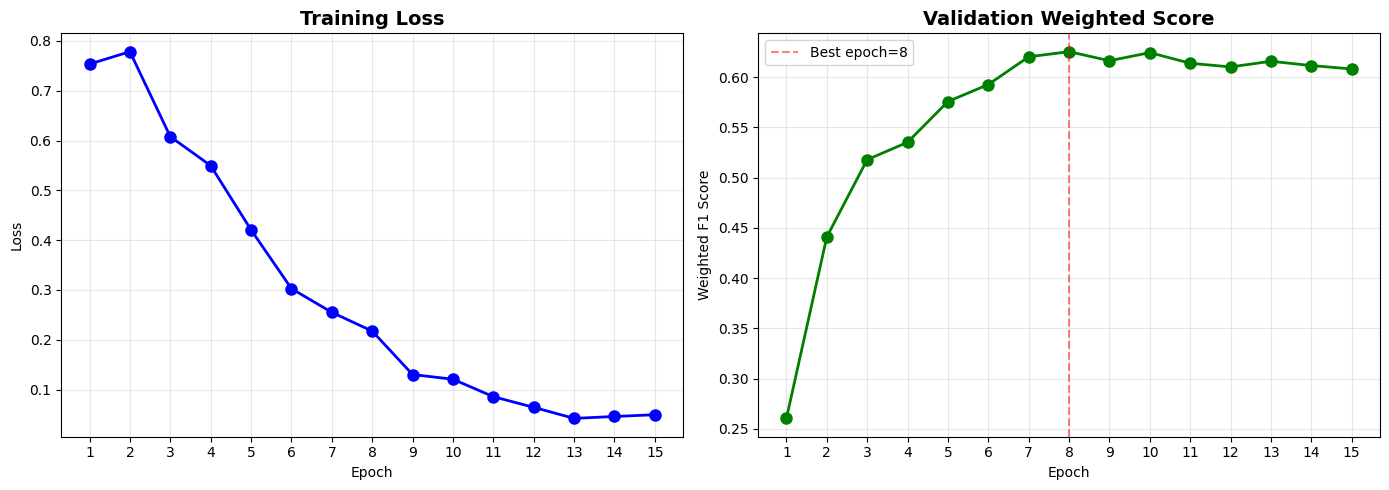

In [ ]:
# 繪製訓練曲線
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["loss"], 'b-o', linewidth=2, markersize=8)
axes[0].set_title("Training Loss", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs_range)

axes[1].plot(epochs_range, history["weighted_score"], 'g-o', linewidth=2, markersize=8)
axes[1].set_title("Validation Weighted Score", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weighted F1 Score")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs_range)

# 標記最佳點
best_epoch = history["weighted_score"].index(max(history["weighted_score"])) + 1
axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best epoch={best_epoch}')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curve.png", dpi=150, bbox_inches='tight')
plt.show()

---

## Step 9: 最終評估與結果分析

訓練完成後，載入最佳模型並進行詳細的結果分析。

In [ ]:
# ================================
# 產生 AI CUP 正式 submission.csv
# ================================

import json
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

TEST_PATH = "vpesg4k_test_2000.json"
SUBMISSION_PATH = "submission.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 讀取正式測試集
with open(TEST_PATH, "r", encoding="utf-8") as f:
    test_data = json.load(f)

print("測試資料筆數：", len(test_data))
print("第一筆欄位：", test_data[0].keys())


# ================================
# 自動找文字欄位
# ================================

possible_text_keys = ["data", "text", "paragraph", "content"]

TEXT_KEY = None
for key in possible_text_keys:
    if key in test_data[0]:
        TEXT_KEY = key
        break

if TEXT_KEY is None:
    raise ValueError(f"找不到文字欄位，請檢查 test_data[0].keys() = {test_data[0].keys()}")

print("使用文字欄位：", TEXT_KEY)


# ================================
# Test Dataset
# ================================

class ESGTestDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        original_text = item[TEXT_KEY]

        # 如果你的前面程式有 build_feature_prefix，就沿用
        try:
            feature_prefix = build_feature_prefix(original_text)
            combined_text = f"{feature_prefix}{original_text}"
        except:
            combined_text = original_text

        encoding = self.tokenizer(
            combined_text,
            truncation=True,
            max_length=MAX_LEN,
            padding="max_length",
            return_tensors="pt"
        )

        output = {
            "id": item["id"],
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
        }

        # 如果你的模型有使用 LSA，就加入 lsa_feat
        if "vectorizer" in globals() and "lsa_obj" in globals():
            tfidf_feat = vectorizer.transform([original_text])
            lsa_feat = lsa_obj.transform(tfidf_feat)[0]
            output["lsa_feat"] = torch.tensor(lsa_feat, dtype=torch.float)

        return output


def test_collate_fn(batch):
    output = {
        "id": [item["id"] for item in batch],
        "input_ids": torch.stack([item["input_ids"] for item in batch]),
        "attention_mask": torch.stack([item["attention_mask"] for item in batch]),
    }

    if "lsa_feat" in batch[0]:
        output["lsa_feat"] = torch.stack([item["lsa_feat"] for item in batch])

    return output


test_dataset = ESGTestDataset(test_data, tokenizer)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=test_collate_fn
)

def get_label_id(field, label):
    for k, v in id2label[field].items():
        if v == label:
            return k
    return None

# ================================
# 5-Fold Ensemble Prediction
# ================================

def predict_test_ensemble(model_paths, test_loader, device, id2label):
    all_fold_probs = []
    all_ids = None

    for model_path in model_paths:
        print(f"載入模型：{model_path}")

        model = MultiTaskBert(num_labels).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()

        fold_probs = {field: [] for field in EVAL_FIELDS}
        ids = []

        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)

                if "lsa_feat" in batch:
                    lsa_feat = batch["lsa_feat"].to(device)
                    logits = model(input_ids, attention_mask, lsa_feat)
                else:
                    logits = model(input_ids, attention_mask)

                ids.extend(batch["id"])

                for field in EVAL_FIELDS:
                    probs = F.softmax(logits[field], dim=1).cpu().numpy()
                    fold_probs[field].append(probs)

        fold_probs = {
            field: np.concatenate(fold_probs[field], axis=0)
            for field in EVAL_FIELDS
        }

        if all_ids is None:
            all_ids = ids

        all_fold_probs.append(fold_probs)

    avg_probs = {}

    for field in EVAL_FIELDS:
        avg_probs[field] = np.mean(
            [fold_probs[field] for fold_probs in all_fold_probs],
            axis=0
        )

    predictions = []

    for i in range(len(all_ids)):
        pred = {"id": all_ids[i]}
        pred.update(constrained_decode_one(i, avg_probs))
        predictions.append(pred)

    return predictions


def constrained_decode_one(i, avg_probs):
    pred = {}

    # ========== 1. promise_status ==========
    promise_probs = avg_probs["promise_status"][i]
    promise_id = promise_probs.argmax()
    promise_label = id2label["promise_status"][promise_id]

    pred["promise_status"] = promise_label

    # 如果不是承諾，後面全部固定 N/A
    if promise_label == "No":
        pred["verification_timeline"] = "N/A"
        pred["evidence_status"] = "N/A"
        pred["evidence_quality"] = "N/A"
        return pred

    # ========== 2. verification_timeline ==========
    # promise_status = Yes 時，不允許 timeline = N/A
    timeline_probs = avg_probs["verification_timeline"][i].copy()

    timeline_na_id = get_label_id("verification_timeline", "N/A")
    if timeline_na_id is not None:
        timeline_probs[timeline_na_id] = -1

    timeline_id = timeline_probs.argmax()
    timeline_label = id2label["verification_timeline"][timeline_id]

    if timeline_label == "longer_than_5_years":
        timeline_label = "more_than_5_years"

    pred["verification_timeline"] = timeline_label

    # ========== 3. evidence_status ==========
    # promise_status = Yes 時，不允許 evidence_status = N/A
    evidence_probs = avg_probs["evidence_status"][i].copy()

    evidence_na_id = get_label_id("evidence_status", "N/A")
    if evidence_na_id is not None:
        evidence_probs[evidence_na_id] = -1

    evidence_id = evidence_probs.argmax()
    evidence_label = id2label["evidence_status"][evidence_id]

    pred["evidence_status"] = evidence_label

    # ========== 4. evidence_quality ==========
    if evidence_label == "No":
        pred["evidence_quality"] = "N/A"
        return pred

    # evidence_status = Yes 時，不允許 quality = N/A
    quality_probs = avg_probs["evidence_quality"][i].copy()

    quality_na_id = get_label_id("evidence_quality", "N/A")
    if quality_na_id is not None:
        quality_probs[quality_na_id] = -1

    quality_id = quality_probs.argmax()
    quality_label = id2label["evidence_quality"][quality_id]

    pred["evidence_quality"] = quality_label

    return pred

    return predictions


model_paths = [
    "best_model_fold1.pt",
    "best_model_fold2.pt",
    "best_model_fold3.pt",
    "best_model_fold4.pt",
    "best_model_fold5.pt",
]

test_preds = predict_test_ensemble(model_paths, test_loader, device, id2label)


# ================================
# 官方邏輯後處理
# ================================

def post_process(pred):
    if pred["verification_timeline"] == "longer_than_5_years":
        pred["verification_timeline"] = "more_than_5_years"

    if pred["promise_status"] == "No":
        pred["verification_timeline"] = "N/A"
        pred["evidence_status"] = "N/A"
        pred["evidence_quality"] = "N/A"

    else:
        if pred["verification_timeline"] == "N/A":
            pred["verification_timeline"] = "already"

        if pred["evidence_quality"] in ["Clear", "Not Clear", "Misleading"]:
            pred["evidence_status"] = "Yes"

        if pred["evidence_status"] in ["No", "N/A"]:
            pred["evidence_quality"] = "N/A"

    return pred


test_preds = [post_process(pred) for pred in test_preds]


# ================================
# 輸出 submission.csv
# ================================

submission = pd.DataFrame(test_preds)

submission = submission[
    [
        "id",
        "promise_status",
        "verification_timeline",
        "evidence_status",
        "evidence_quality"
    ]
]

# 不要照原本 id 排序，直接依照 test 資料順序重新編號
submission = submission.reset_index(drop=True)

# 官方要求 id 必須是 12001 ~ 14000
submission["id"] = range(12001, 12001 + len(submission))

# 固定欄位順序
submission = submission[
    [
        "id",
        "promise_status",
        "verification_timeline",
        "evidence_status",
        "evidence_quality"
    ]
]

print("submission shape:", submission.shape)
print(submission.head())
print(submission.tail())
print(submission.isna().sum())

assert submission.shape[0] == 2000, "錯誤：submission 不是 2000 筆"
assert submission["id"].iloc[0] == 12001, "錯誤：第一筆 id 不是 12001"
assert submission["id"].iloc[-1] == 14000, "錯誤：最後一筆 id 不是 14000"

submission.to_csv("submission.csv", index=False, encoding="utf-8-sig")

print("完成！已產生 submission.csv")

測試資料筆數： 2000
第一筆欄位： dict_keys(['id', 'data', 'company', 'ticker', 'page_number', 'pdf_url', 'company_source'])
使用文字欄位： data
載入模型：best_model_fold1.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


載入模型：best_model_fold2.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


載入模型：best_model_fold5.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


submission shape: (2000, 5)
      id promise_status  verification_timeline evidence_status  \
0  12001            Yes                already             Yes   
1  12002            Yes  between_2_and_5_years             Yes   
2  12003            Yes         within_2_years             Yes   
3  12004            Yes  between_2_and_5_years             Yes   
4  12005            Yes                already             Yes   

  evidence_quality  
0            Clear  
1            Clear  
2            Clear  
3            Clear  
4            Clear  
         id promise_status  verification_timeline evidence_status  \
1995  13996            Yes  between_2_and_5_years             Yes   
1996  13997            Yes                already             Yes   
1997  13998            Yes                already             Yes   
1998  13999            Yes  between_2_and_5_years             Yes   
1999  14000            Yes      more_than_5_years             Yes   

     evidence_quality  
1995      

In [ ]:
# ================================
# 用 validation 找最佳 threshold，並產生新的 submission.csv
# ================================

import json
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

VAL_PATH = "vpesg4k_val_1000.csv"
TEST_PATH = "vpesg4k_test_2000.json"
SUBMISSION_PATH = "submission_threshold.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_paths = [
    "best_model_fold1.pt",
    "best_model_fold2.pt",
    "best_model_fold3.pt",
    "best_model_fold4.pt",
    "best_model_fold5.pt",
]

# ================================
# 讀取 validation / test
# ================================

val_df = pd.read_csv(VAL_PATH)
val_data = val_df.to_dict("records")

with open(TEST_PATH, "r", encoding="utf-8") as f:
    test_data = json.load(f)

print("val 筆數:", len(val_data))
print("test 筆數:", len(test_data))
print("val 欄位:", val_df.columns.tolist())
print("test 欄位:", test_data[0].keys())


# ================================
# 自動找文字欄位
# ================================

def find_text_key(sample):
    for key in ["data", "text", "paragraph", "content"]:
        if key in sample:
            return key
    raise ValueError(f"找不到文字欄位: {sample.keys()}")

VAL_TEXT_KEY = find_text_key(val_data[0])
TEST_TEXT_KEY = find_text_key(test_data[0])

print("VAL_TEXT_KEY =", VAL_TEXT_KEY)
print("TEST_TEXT_KEY =", TEST_TEXT_KEY)


# ================================
# Dataset
# ================================

class ESGInferDataset(Dataset):
    def __init__(self, data, tokenizer, text_key):
        self.data = data
        self.tokenizer = tokenizer
        self.text_key = text_key

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        original_text = str(item[self.text_key])

        try:
            feature_prefix = build_feature_prefix(original_text)
            combined_text = f"{feature_prefix}{original_text}"
        except:
            combined_text = original_text

        encoding = self.tokenizer(
            combined_text,
            truncation=True,
            max_length=MAX_LEN,
            padding="max_length",
            return_tensors="pt"
        )

        output = {
            "id": item.get("id", idx),
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
        }

        if "vectorizer" in globals() and "lsa_obj" in globals():
            tfidf_feat = vectorizer.transform([original_text])
            lsa_feat = lsa_obj.transform(tfidf_feat)[0]
            output["lsa_feat"] = torch.tensor(lsa_feat, dtype=torch.float)

        return output


def infer_collate_fn(batch):
    output = {
        "id": [item["id"] for item in batch],
        "input_ids": torch.stack([item["input_ids"] for item in batch]),
        "attention_mask": torch.stack([item["attention_mask"] for item in batch]),
    }

    if "lsa_feat" in batch[0]:
        output["lsa_feat"] = torch.stack([item["lsa_feat"] for item in batch])

    return output


val_loader_new = DataLoader(
    ESGInferDataset(val_data, tokenizer, VAL_TEXT_KEY),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=infer_collate_fn
)

test_loader_new = DataLoader(
    ESGInferDataset(test_data, tokenizer, TEST_TEXT_KEY),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=infer_collate_fn
)


# ================================
# 取得 5-fold ensemble 機率
# ================================

def get_ensemble_probs(model_paths, loader):
    all_fold_probs = []
    all_ids = None

    for model_path in model_paths:
        print("載入:", model_path)

        model = MultiTaskBert(num_labels).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()

        fold_probs = {field: [] for field in EVAL_FIELDS}
        ids = []

        with torch.no_grad():
            for batch in loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)

                if "lsa_feat" in batch:
                    lsa_feat = batch["lsa_feat"].to(device)
                    logits = model(input_ids, attention_mask, lsa_feat)
                else:
                    logits = model(input_ids, attention_mask)

                ids.extend(batch["id"])

                for field in EVAL_FIELDS:
                    probs = F.softmax(logits[field], dim=1).cpu().numpy()
                    fold_probs[field].append(probs)

        fold_probs = {
            field: np.concatenate(fold_probs[field], axis=0)
            for field in EVAL_FIELDS
        }

        if all_ids is None:
            all_ids = ids

        all_fold_probs.append(fold_probs)

    avg_probs = {}
    for field in EVAL_FIELDS:
        avg_probs[field] = np.mean(
            [fold_probs[field] for fold_probs in all_fold_probs],
            axis=0
        )

    return all_ids, avg_probs


val_ids, val_probs = get_ensemble_probs(model_paths, val_loader_new)
test_ids, test_probs = get_ensemble_probs(model_paths, test_loader_new)


# ================================
# 根據 threshold 轉成 label
# ================================

def probs_to_preds(ids, probs, threshold=0.5):
    preds = []

    promise_yes_id = None
    for k, v in id2label["promise_status"].items():
        if v == "Yes":
            promise_yes_id = k

    for i in range(len(ids)):
        pred = {"id": ids[i]}

        for field in EVAL_FIELDS:
            pred_id = probs[field][i].argmax()
            pred[field] = id2label[field][pred_id]

        # promise_status 用 threshold 修正
        yes_prob = probs["promise_status"][i][promise_yes_id]

        if yes_prob >= threshold:
            pred["promise_status"] = "Yes"
        else:
            pred["promise_status"] = "No"

        pred = post_process_for_submission(pred)
        preds.append(pred)

    return preds


# ================================
# 官方邏輯後處理
# ================================

def post_process_for_submission(pred):
    if pred["verification_timeline"] == "longer_than_5_years":
        pred["verification_timeline"] = "more_than_5_years"

    if pred["promise_status"] == "No":
        pred["verification_timeline"] = "N/A"
        pred["evidence_status"] = "N/A"
        pred["evidence_quality"] = "N/A"
    else:
        if pred["verification_timeline"] == "N/A":
            pred["verification_timeline"] = "already"

        if pred["evidence_quality"] in ["Clear", "Not Clear", "Misleading"]:
            pred["evidence_status"] = "Yes"

        if pred["evidence_status"] in ["No", "N/A"]:
            pred["evidence_quality"] = "N/A"

    return pred


# ================================
# 在 validation 上找最佳 threshold
# ================================

thresholds = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
best_threshold = 0.5
best_score = -1

for th in thresholds:
    val_preds = probs_to_preds(val_ids, val_probs, threshold=th)

    results = evaluate_hybrid(val_data, val_preds)
    score = results["final_weighted_score"]

    print(f"threshold={th:.2f}, val score={score:.5f}")

    if score > best_score:
        best_score = score
        best_threshold = th

print("最佳 threshold:", best_threshold)
print("最佳 validation score:", best_score)


# ================================
# 用最佳 threshold 產生 test submission
# ================================

test_preds = probs_to_preds(test_ids, test_probs, threshold=best_threshold)

submission = pd.DataFrame(test_preds)

submission = submission[
    [
        "id",
        "promise_status",
        "verification_timeline",
        "evidence_status",
        "evidence_quality"
    ]
]

# 依照官方要求，強制 id 為 12001~14000
submission = submission.reset_index(drop=True)
submission["id"] = range(12001, 12001 + len(submission))

print(submission.head())
print(submission.tail())
print(submission.shape)
print(submission.isna().sum())

assert submission.shape[0] == 2000
assert submission["id"].iloc[0] == 12001
assert submission["id"].iloc[-1] == 14000

submission.to_csv(SUBMISSION_PATH, index=False, encoding="utf-8-sig")

print(f"完成！已產生 {SUBMISSION_PATH}")
print(f"使用 threshold = {best_threshold}")

val 筆數: 1000
test 筆數: 2000
val 欄位: ['id', 'data', 'esg_type', 'promise_status', 'promise_string', 'verification_timeline', 'evidence_status', 'evidence_string', 'evidence_quality', 'company', 'ticker', 'page_number', 'pdf_url', 'company_source']
test 欄位: dict_keys(['id', 'data', 'company', 'ticker', 'page_number', 'pdf_url', 'company_source'])
VAL_TEXT_KEY = data
TEST_TEXT_KEY = data
載入: best_model_fold1.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


載入: best_model_fold2.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


載入: best_model_fold5.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


threshold=0.35, val score=0.43255
threshold=0.40, val score=0.43614
threshold=0.45, val score=0.43426
threshold=0.50, val score=0.43616
threshold=0.55, val score=0.43206
threshold=0.60, val score=0.43160
threshold=0.65, val score=0.43017
最佳 threshold: 0.5
最佳 validation score: 0.43615686020630023
      id promise_status  verification_timeline evidence_status  \
0  12001            Yes                already             Yes   
1  12002            Yes                already             Yes   
2  12003            Yes  between_2_and_5_years             Yes   
3  12004            Yes  between_2_and_5_years             Yes   
4  12005            Yes                already             Yes   

  evidence_quality  
0            Clear  
1            Clear  
2            Clear  
3            Clear  
4            Clear  
         id promise_status  verification_timeline evidence_status  \
1995  13996            Yes  between_2_and_5_years             Yes   
1996  13997            Yes                

In [ ]:
# 載入最佳模型
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
print(f"已載入最佳模型")

# 最終預測
final_preds = predict(model, val_loader, device, id2label)
final_results = evaluate_hybrid(val_data, final_preds)

print(f"\n{'=' * 60}")
print(f"最終評估結果")
print(f"{'=' * 60}")

for field in EVAL_FIELDS:
    r = final_results[field]
    print(f"\n--- {field} (權重: {r['weight']}) ---")
    print(r["report"])
    print(f"  Macro F1: {r['macro_f1']:.4f}")
    print(f"  Micro F1: {r['micro_f1']:.4f}")

print(f"\n{'=' * 60}")
print(f"最終加權分數: {final_results['final_weighted_score']:.5f}")
print(f"{'=' * 60}")

FileNotFoundError: [Errno 2] No such file or directory: 'best_model.pt'

In [ ]:
3# 視覺化各欄位的 F1 分數
fields = list(EVAL_FIELDS.keys())
macro_f1s = [final_results[f]["macro_f1"] for f in fields]
micro_f1s = [final_results[f]["micro_f1"] for f in fields]
weights   = [FIELD_WEIGHTS[f] for f in fields]

x = range(len(fields))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], macro_f1s, width, label='Macro F1', color='steelblue', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], micro_f1s, width, label='Micro F1',  color='coral',     alpha=0.8)

# 加上分數標籤
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel("Task label")
ax.set_ylabel("F1 Score")
ax.set_title(f"F1 Score by Task\nFinal Weighted Score: {final_results['final_weighted_score']:.5f}", fontsize=14, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels([f"{f}\n(w={w})" for f, w in zip(fields, weights)], fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(final_results["final_weighted_score"], color='green', linestyle='--',
           linewidth=2, label=f"Weighted Score={final_results['final_weighted_score']:.4f}")
ax.legend()

plt.tight_layout()
plt.savefig("f1_scores.png", dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'final_results' is not defined

In [ ]:
# --- Step 9: 儲存預測結果 (修正版) ---

OUTPUT_PATH = "prediction.json"

output_data = []
for orig, pred in zip(val_data, final_preds):
    # 1. 複製原始資料字典，避免改動到原始 val_data
    item = dict(orig)

    # 2. 覆蓋預測欄位
    item.update(pred)

    # 3. 【核心修正】移除無法 JSON 序列化的 NumPy 陣列欄位
    # pop(key, None) 的意思是：如果有這個欄位就刪除，沒有也不會報錯
    item.pop('lsa_feature', None)

    output_data.append(item)

# 4. 執行儲存
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

print(f"✅ 預測結果已成功儲存至: {OUTPUT_PATH}")
print(f"   共 {len(output_data)} 筆，已過濾非序列化特徵。")

# 顯示前 3 筆確認格式
print("\n📋 前 3 筆預測結果（檢查是否包含 LSA）：")
for i, item in enumerate(output_data[:3]):
    has_lsa = "有" if "lsa_feature" in item else "無"
    print(f"--- 第{i+1}筆 (ID: {item.get('id', 'N/A')}) | LSA特徵: {has_lsa} ---")

NameError: name 'final_preds' is not defined

---

## Step 10: 進階改進方向

恭喜你完成了基礎版本！以下是幾個可以進一步提升分數的方向：

### 1. 模型升級
```python
# 可以嘗試更大的模型
MODEL_NAME = "hfl/chinese-roberta-wwm-ext-large"  # 中文 RoBERTa Large
MODEL_NAME = "bert-large-chinese"                   # BERT Large
```

### 2. 加入 Dropout 防止過擬合
```python
self.dropout = nn.Dropout(0.1)
pooled = self.dropout(outputs.pooler_output)
```

### 3. 損失加權（針對類別不均衡）
```python
# 給少數類別更高的損失權重
criterion = nn.CrossEntropyLoss(weight=class_weights)
```

### 4. 資料增強
- 同義詞替換
- 回譯（中→英→中）
- 隨機遮罩

### 5. 集成學習（Ensemble）
```python
# 訓練多個模型，取預測結果的多數票
from collections import Counter
ensemble_pred = Counter([model1_pred, model2_pred, model3_pred]).most_common(1)[0][0]
```

### 6. 調整超參數
- 增加 Epochs（10-15）
- 調整 Learning Rate（1e-5 ~ 5e-5）
- 增大 MAX_LEN（512）
- 嘗試不同 BATCH_SIZE

---
## 工作坊總結

今天我們學習了：
1. ESG 承諾驗證任務的定義
2. 使用 EDA 分析資料分佈
3. 實作 PyTorch Dataset & DataLoader
4. 設計 Multi-Task BERT 模型架構
5. 完整的訓練、評估、預測流程
6. 使用加權 Macro F1 評分

**祝大家在比賽中取得好成績！**